# 다중 특성 회귀 모델 파이프라인 구축 및  Streamlit 웹 서비스 배포

In [ ]:
# ==================================================
# 필수 라이브러리 설치
# ==================================================

!pip install streamlit pyngrok joblib -q

In [ ]:
# ==================================================
# 필수 라이브러리 불러오기
# ==================================================

import pandas as pd
import numpy as np

# 데이터 분할
from sklearn.model_selection import train_test_split

# 파이프라인
from sklearn.pipeline import Pipeline

# 데이터 전처리
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures

# 회귀 모델
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge

# 성능 평가
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# 모델 저장
import joblib

# 시각화
import matplotlib.pyplot as plt

In [ ]:
# ==================================================
# WHO 기대수명 데이터셋 불러오기
# ==================================================

url = "https://github.com/dongupak/DataML/raw/main/csv/life_expectancy.csv"

df = pd.read_csv(url)

# 결측치 제거
df = df.dropna()

# 컬럼명 공백 제거
df.columns = df.columns.str.strip()

print("데이터 크기 :", df.shape)

df.head()

In [ ]:
df.columns.tolist()

In [ ]:
# ==================================================
# 독립변수(Feature) 및 종속변수(Target) 선택
# ==================================================

# Schooling 사용 금지

features = [
    'Adult mortality',
    'BMI',
    'GDP',
    'Alcohol'
]

target = 'Life expectancy'

X = df[features]
y = df[target]

print("선택된 특성 :", features)
print("타겟 변수 :", target)

In [ ]:
# ==================================================
# Train / Test 분할
# ==================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train :", X_train.shape)
print("Test :", X_test.shape)

In [ ]:
# ==================================================
# 학습 데이터 50개만 추출
# ==================================================

X_train_small = X_train.sample(
    n=50,
    random_state=42
)

y_train_small = y_train.loc[X_train_small.index]

print("학습 데이터 개수 :", len(X_train_small))

In [ ]:
# ==================================================
# Model 1 : Linear Regression
# ==================================================

linear_model = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

linear_model.fit(
    X_train_small,
    y_train_small
)

In [ ]:
# ==================================================
# Model 2 : Polynomial Regression
# ==================================================

poly_model = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=3)),
    ('regressor', LinearRegression())
])

poly_model.fit(
    X_train_small,
    y_train_small
)

In [ ]:
# ==================================================
# Model 3 : Ridge Regression
# ==================================================

ridge_model = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=3)),
    ('regressor', Ridge(alpha=1.0))
])

ridge_model.fit(
    X_train_small,
    y_train_small
)

In [ ]:
# ==================================================
# 모델 저장
# ==================================================

joblib.dump(linear_model, 'linear.pkl')
joblib.dump(poly_model, 'poly.pkl')
joblib.dump(ridge_model, 'ridge.pkl')

print("모델 저장 완료")

In [ ]:
# ==================================================
# 모델 성능 평가 함수
# ==================================================

def evaluate(model, name):

    train_pred = model.predict(X_train_small)
    test_pred = model.predict(X_test)

    return {
        'Model': name,
        'Train R2': r2_score(y_train_small, train_pred),
        'Test R2': r2_score(y_test, test_pred),
        'Train MSE': mean_squared_error(y_train_small, train_pred),
        'Test MSE': mean_squared_error(y_test, test_pred)
    }

In [ ]:
# ==================================================
# 모델 성능 비교
# ==================================================

results = []

results.append(evaluate(linear_model, "Linear"))
results.append(evaluate(poly_model, "Poly"))
results.append(evaluate(ridge_model, "Ridge"))

result_df = pd.DataFrame(results)

# Complexity 계산
linear_complexity = len(features)

poly_complexity = poly_model.named_steps[
    'poly'
].fit_transform(X).shape[1]

result_df['Complexity'] = [
    linear_complexity,
    poly_complexity,
    poly_complexity
]

result_df

In [ ]:
# ==================================================
# Test R2 비교 그래프
# ==================================================

plt.figure(figsize=(8,5))

plt.bar(
    result_df['Model'],
    result_df['Test R2']
)

plt.title("Model Test R2 Comparison")
plt.ylabel("Test R2")

plt.show()

In [ ]:
%%writefile app.py

# ==================================================
# 다중 특성 회귀 모델 웹 서비스
# ==================================================

import streamlit as st
import pandas as pd
import joblib
import matplotlib.pyplot as plt

# ==================================================
# 저장된 모델 불러오기
# ==================================================

linear_model = joblib.load("linear.pkl")
poly_model = joblib.load("poly.pkl")
ridge_model = joblib.load("ridge.pkl")

# ==================================================
# 웹 페이지 제목
# ==================================================

st.set_page_config(
    page_title="Life Expectancy Prediction",
    layout="wide"
)

st.title("🌎 기대수명 예측 웹 서비스")

st.write(
    "Adult mortality, BMI, GDP, Alcohol 정보를 이용하여 기대수명을 예측합니다."
)

# ==================================================
# 사이드바 입력
# ==================================================

st.sidebar.header("입력값 설정")

adult = st.sidebar.slider(
    "Adult mortality",
    0,
    800,
    150
)

bmi = st.sidebar.slider(
    "BMI",
    0.0,
    80.0,
    25.0
)

gdp = st.sidebar.slider(
    "GDP",
    0,
    120000,
    10000
)

alcohol = st.sidebar.slider(
    "Alcohol",
    0.0,
    20.0,
    5.0
)

# ==================================================
# 모델 선택
# ==================================================

model_name = st.selectbox(
    "모델 선택",
    ["Linear", "Poly", "Ridge"]
)

if model_name == "Linear":
    model = linear_model

elif model_name == "Poly":
    model = poly_model

else:
    model = ridge_model

# ==================================================
# 입력 데이터 생성
# ==================================================

input_data = pd.DataFrame({
    "Adult mortality": [adult],
    "BMI": [bmi],
    "GDP": [gdp],
    "Alcohol": [alcohol]
})

# ==================================================
# 예측 수행
# ==================================================

prediction = model.predict(input_data)

# ==================================================
# 예측 결과 출력
# ==================================================

st.header("예측 결과")

st.metric(
    label="예상 기대수명",
    value=f"{prediction[0]:.2f} 세"
)

result_df = pd.read_csv("result_df.csv")

# ==================================================
# 성능 비교 테이블
# ==================================================

st.subheader("모델 성능 비교")

st.dataframe(result_df)

# ==================================================
# Test R2 그래프
# ==================================================

fig, ax = plt.subplots()

ax.bar(
    result_df["Model"],
    result_df["Test R2"]
)

ax.set_ylabel("Test R2")

st.pyplot(fig)

In [ ]:
result_df.to_csv("result_df.csv", index=False)

In [ ]:
!pip install pyngrok streamlit -q

In [ ]:
from pyngrok import ngrok
import os

In [ ]:
ngrok.set_auth_token("3Ef1K2nnCUcsqGUGetFeijTrCLh_3PmW9SYpX1EVBnPTdXsKM")

In [ ]:
os.system("streamlit run app.py &")

In [ ]:
public_url = ngrok.connect(8501)

print(public_url)

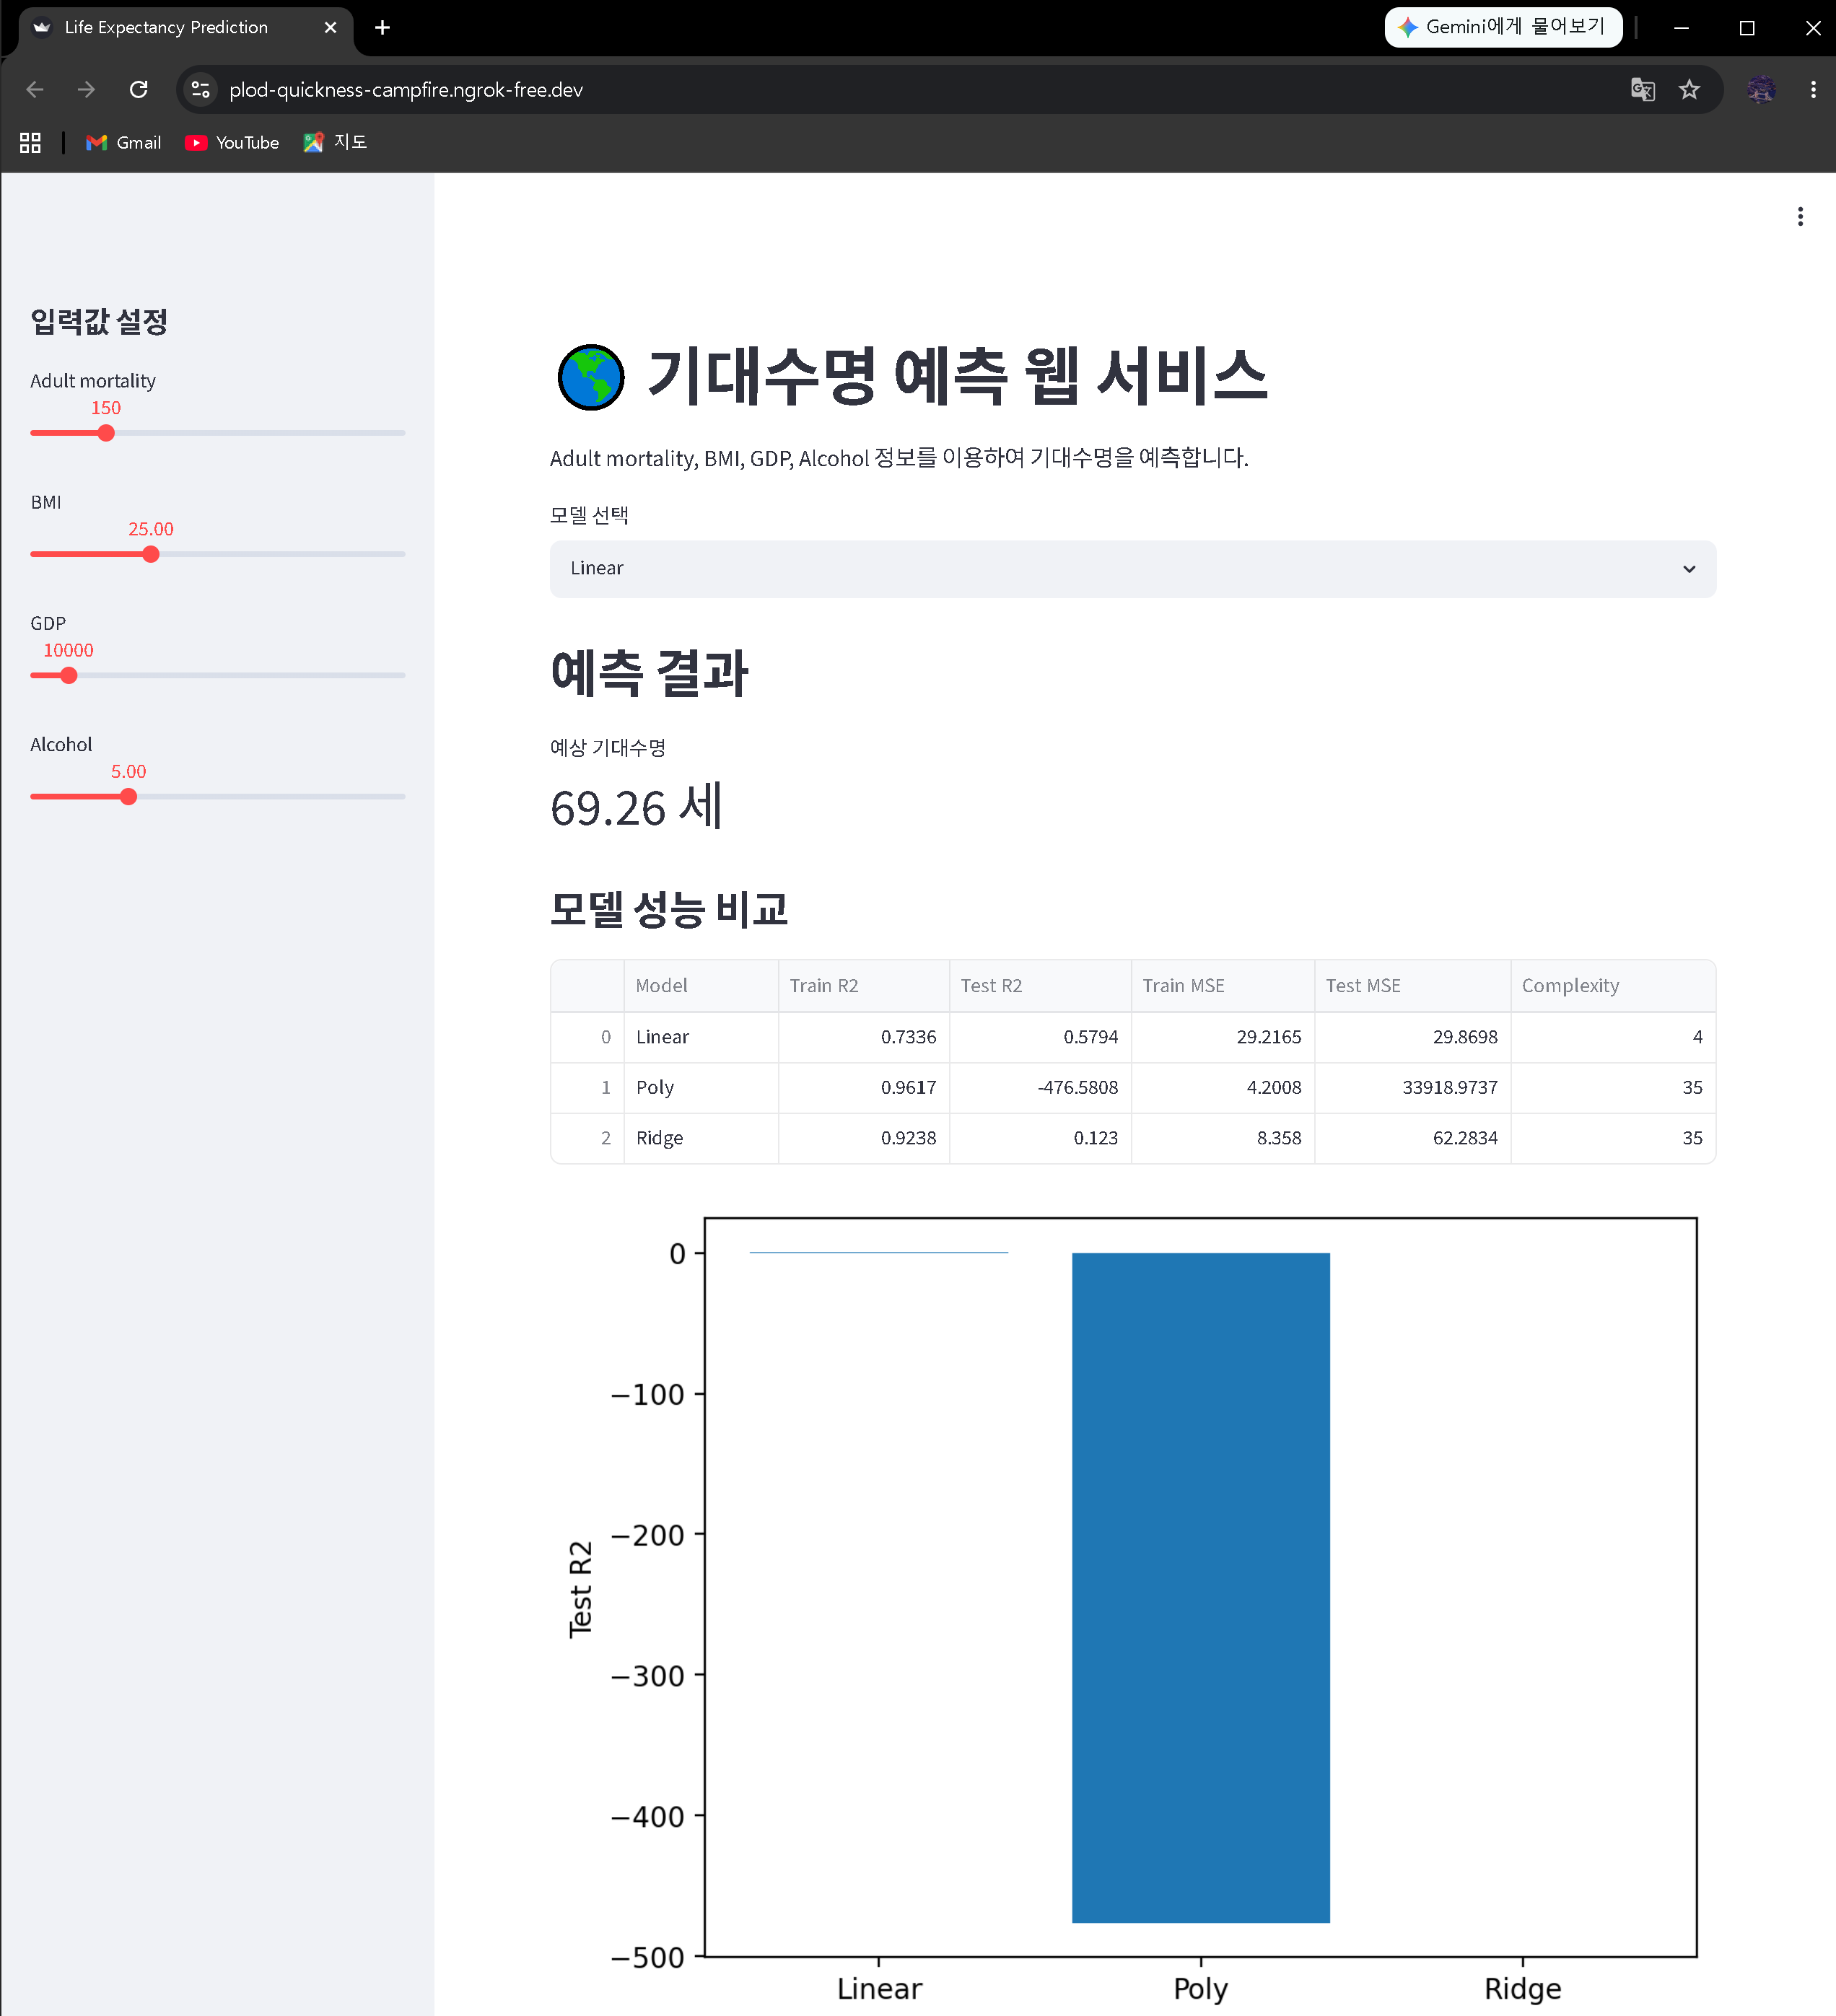

In [ ]:
!ls